Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Path to your outputs root
OUTPUT_ROOT = Path("/data/horse/ws/rabo074f-team_project/BYU2/outputs")

# Sigma and thresholds to consider
SIGMAS = ["sigma4", "sigma8", "sigma12", "sigma16"]
THRESHOLDS = [0.05, 0.1, 0.2,0.4,0.5]

Load metrics

In [2]:
def load_metrics_for_sigma_threshold(sigma, threshold):
    csv_path = OUTPUT_ROOT / sigma / f"threshold_{threshold}" / "metrics.csv"
    if not csv_path.exists():
        return None

    df = pd.read_csv(csv_path)
    df["sigma"] = sigma
    df["threshold"] = threshold
    return df

all_dfs = []
for sigma in SIGMAS:
    for thr in THRESHOLDS:
        df = load_metrics_for_sigma_threshold(sigma, thr)
        if df is not None:
            all_dfs.append(df)

results_df = pd.concat(all_dfs, ignore_index=True)
results_df.head()

,tomo_id,tp,fp,fn,precision,recall,f1,f2,num_pred,num_gt,pred_coords_vox,gt_coords_vox,sigma,threshold
0,tomo_02862f,1,31,0,0.03125,1.0,0.060606,0.138889,32,1,"[[71, 92, 80], [53, 50, 17], [52, 89, 82], [37...","[[15, 47, 17]]",sigma4,0.05
1,tomo_03437b,1,31,0,0.03125,1.0,0.060606,0.138889,32,1,"[[69, 57, 28], [19, 112, 84], [46, 63, 27], [7...","[[52, 115, 86]]",sigma4,0.05
2,tomo_04d42b,0,0,0,1.00000,1.0,1.000000,1.000000,0,0,[],[],sigma4,0.05
3,tomo_05b39c,0,0,0,1.00000,1.0,1.000000,1.000000,0,0,[],[],sigma4,0.05
4,tomo_072a16,0,10,0,0.00000,1.0,0.000000,0.000000,10,0,"[[82, 69, 89], [125, 55, 91], [80, 45, 85], [1...",[],sigma4,0.05


In [3]:
counts_per_sigma = results_df["sigma"].value_counts().sort_index()

print("Counts per sigma:")
for sigma, count in counts_per_sigma.items():
    print(f"  {sigma:<8}: {count}")

# Total rows (all sigma + thresholds)
total_rows = len(results_df)
print(f"\nTotal rows in results_df: {total_rows}")

Counts per sigma:
  sigma12 : 660
  sigma16 : 660
  sigma4  : 660
  sigma8  : 660

Total rows in results_df: 2640


In [4]:
#Print the last few rows to verify
print("\nLast few rows of results_df:")
print(results_df.tail())


Last few rows of results_df:
          tomo_id  tp   fp  fn  precision    recall        f1        f2  \
2635  tomo_f82a15   0    0   0   1.000000  1.000000  1.000000  1.000000   
2636  tomo_f8b835   0    0   0   1.000000  1.000000  1.000000  1.000000   
2637  tomo_fd5b38   1    1   0   0.500000  1.000000  0.666667  0.833333   
2638  tomo_fe85f6   0    0   0   1.000000  1.000000  1.000000  1.000000   
2639      OVERALL  29  281  64   0.093548  0.311828  0.143921  0.212610   

      num_pred  num_gt                pred_coords_vox   gt_coords_vox  \
2635         0       0                             []              []   
2636         0       0                             []              []   
2637         2       1  [[122, 71, 84], [91, 68, 86]]  [[98, 69, 86]]   
2638         0       0                             []              []   
2639       310      93                            NaN             NaN   

        sigma  threshold  
2635  sigma16        0.5  
2636  sigma16        0.5  

Extract overall rows and compare global metrics

In [5]:
overall_df = results_df[results_df["tomo_id"] == "OVERALL"].copy()
overall_df["sigma_num"] = overall_df["sigma"].str.extract(r"(\d+)").astype(int)
overall_df.sort_values(["sigma_num", "threshold"], inplace=True)
display(overall_df.reset_index(drop=True)[["sigma", "threshold", "f2", "f1", "precision", "recall"]])

,sigma,threshold,f2,f1,precision,recall
0,sigma4,0.05,0.157171,0.076923,0.041558,0.516129
1,sigma4,0.10,0.159363,0.081967,0.045300,0.430108
2,sigma4,0.20,0.164569,0.090186,0.051437,0.365591
3,sigma4,0.40,0.156069,0.092150,0.054767,0.290323
4,sigma4,0.50,0.154131,0.093985,0.056948,0.268817
5,sigma8,0.05,0.224660,0.126844,0.073504,0.462366
6,sigma8,0.10,0.223267,0.132867,0.079332,0.408602
7,sigma8,0.20,0.224274,0.141962,0.088083,0.365591
8,sigma8,0.40,0.225225,0.155039,0.102041,0.322581
9,sigma8,0.50,0.221870,0.159091,0.108108,0.301075


Plot global F₁ across sigmas and thresholds

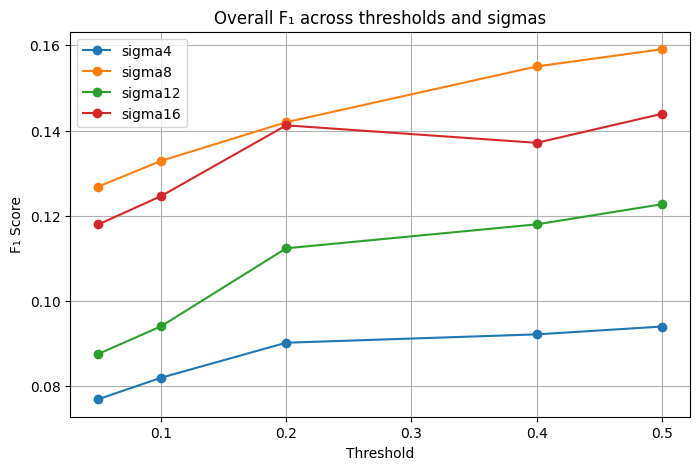

In [7]:
import os

save_dir = "images_hpc/test_output_visualization_images/test_output_visualization_pdfs"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(8,5))
for sigma in SIGMAS:
    subset = overall_df[overall_df["sigma"] == sigma]
    plt.plot(subset["threshold"], subset["f1"], marker="o", label=sigma)
plt.title("Overall F₁ across thresholds and sigmas")
plt.xlabel("Threshold")
plt.ylabel("F₁ Score")
plt.legend()
plt.grid(True)

plt.savefig(f"{save_dir}/overall_f1_across_thresholds_sigmas.pdf", format="pdf", bbox_inches="tight")

plt.show()
plt.close()

Plot global F₂ across sigmas and thresholds

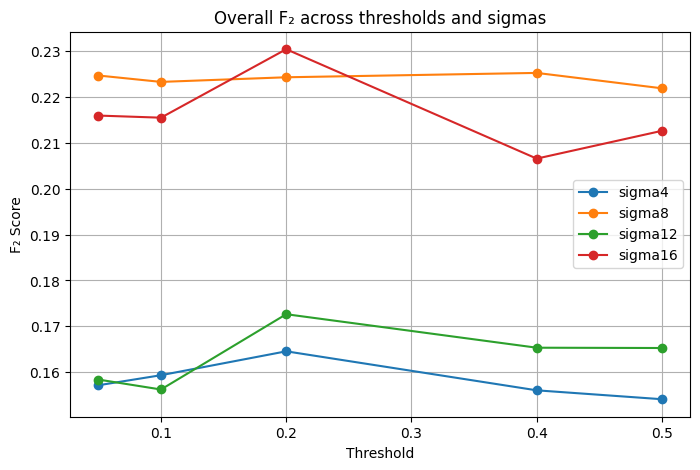

In [8]:
plt.figure(figsize=(8,5))
for sigma in SIGMAS:
    subset = overall_df[overall_df["sigma"] == sigma]
    plt.plot(subset["threshold"], subset["f2"], marker="o", label=sigma)
plt.title("Overall F₂ across thresholds and sigmas")
plt.xlabel("Threshold")
plt.ylabel("F₂ Score")
plt.legend()
plt.grid(True)

plt.savefig(f"{save_dir}/overall_f2_across_thresholds_sigmas.pdf", format="pdf", bbox_inches="tight")

plt.show()
plt.close()

Compare precision–recall trade-offs

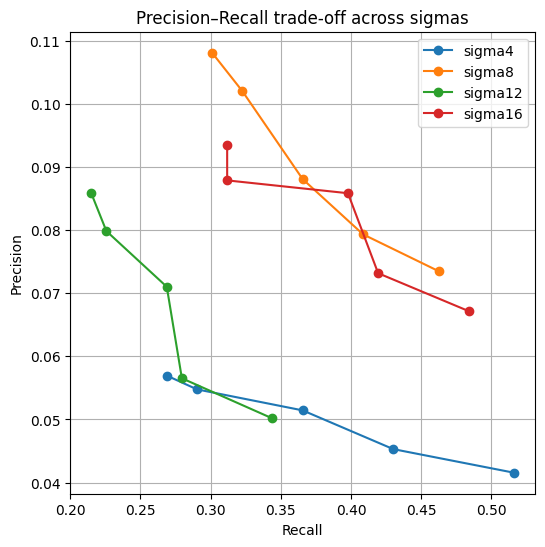

In [9]:
plt.figure(figsize=(6,6))
for sigma in SIGMAS:
    subset = overall_df[overall_df["sigma"] == sigma]
    plt.plot(subset["recall"], subset["precision"], marker="o", label=sigma)
plt.title("Precision–Recall trade-off across sigmas")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)

plt.savefig(f"{save_dir}/precision_recall_tradeoff_across_sigmas.pdf", format="pdf", bbox_inches="tight")

plt.show()
plt.close()

- Larger σ in the GT heatmap during training encourages smoother predictions. At inference, that typically reduces false positives (↑precision) but can miss weaker motors (↓recall).

- Threshold choice slides you along each sigma’s curve:
    - Lower thr → more detections (↑recall, ↓precision).
    - Higher thr → fewer detections (↓recall, ↑precision).

best combination summary

In [10]:
best = overall_df.loc[overall_df.groupby("sigma")["f2"].idxmax()]
best = best.reset_index(drop=True)
print("\nBest F2 scores per sigma:")
display(best[["sigma", "threshold", "f2", "precision", "recall"]])

# Save table as a simple PDF
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = f"{save_dir}/best_f2_scores_per_sigma.pdf"
with PdfPages(pdf_path) as pdf:
    fig, ax = plt.subplots(figsize=(8, 2 + 0.4 * len(best)))
    ax.axis("off")
    table = ax.table(
        cellText=best[["sigma", "threshold", "f2", "precision", "recall"]].round(4).values,
        colLabels=["Sigma", "Threshold", "F2", "Precision", "Recall"],
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"Table saved as PDF: {pdf_path}")


Best F2 scores per sigma:


,sigma,threshold,f2,precision,recall
0,sigma12,0.2,0.172652,0.071023,0.268817
1,sigma16,0.2,0.230386,0.085847,0.397849
2,sigma4,0.2,0.164569,0.051437,0.365591
3,sigma8,0.4,0.225225,0.102041,0.322581


Table saved as PDF: images_hpc/test_output_visualization_images/test_output_visualization_pdfs/best_f2_scores_per_sigma.pdf
